In [37]:
#goa266 homework-2

In [38]:
#DISCUSSION ANSWER

#at relatively small x-values increasing the amount of terms generally gets a more accurate answer.
#error grows inreasingly as x increases for n [2,4] and plateaus around x= ~4.5 for n=1
#for x values > ~5.25 when n is [1,4] truncation error leads to n=1 becoming an increasingly more accurate estimation (compared to n=2,3,4) as x increases

In [39]:
import numpy as np
import matplotlib.pyplot as plt

lotsOfDebug = False

#if true will seperate graphs into x=[0,pi] [pi,2pi] [2pi,3pi] [3pi,4pi]
discussionAnalysisMode = False

In [40]:
def factorialFunc(inputVal):
    output = inputVal
    startVal = inputVal-1
    
    for i in range (startVal,0,-1):
        output = i*output
    return output

In [41]:
#sum of (-1^n)*(x^2n+1)/!(2n+1) where n = iterations
def taylorSeries(xVal,iterations):
    output = 0
    for i in range (0,iterations,1):
        numerator = (-1)**i

        nTerm = 2*i+1
        xTerm = xVal**nTerm

        numerator *= xTerm
        denominator = factorialFunc(nTerm)
        
        output += numerator/denominator
    return output

In [42]:
#finds the abs. difference between np.sin and taylor-approximation
def errorCalculation(xVal,taySeriesOut):
    trueVal = np.sin(xVal)
    absError = np.abs(trueVal-taySeriesOut)
    return absError

In [43]:
#x-axis is input values [0,4pi] y-axis is abs. error
#each color shows the abs. error at different truncation values n->[1,4]
def plotFunc(xList,inputArray):
    print('\nplot init')
    plt.figure()
    dotSize = 7
    plt.scatter(xList,inputArray[0,:],color='red',label='n=1', s = dotSize)
    plt.scatter(xList,inputArray[1,:],color='blue',label='n=2', s = dotSize)
    plt.scatter(xList,inputArray[2,:],color='green',label='n=3', s = dotSize)
    plt.scatter(xList,inputArray[3,:],color='orange',label='n=4', s = dotSize)

    #makes domain values more friendly for label
    deciPlace = 2
    xStrStart = round(xList[0],deciPlace)
    xStrEnd = round(xList[-1],deciPlace)
    plt.xlabel(f'x-values ({xStrStart},{xStrEnd})')
    plt.ylabel('abs-error')
    
    plt.legend()
    plt.plot()
    print('plot completed\n')
    

In [44]:
def hw2Func(startVal,endVal):
    print('hw2Func func init')
    #startVal = 0
    #endVal = 1*np.pi
    stepSize = 0.1
    truncStart = 1
    truncEnd = 4
    
    xValList = np.arange(startVal,endVal,stepSize)
    xValLen = len(xValList)
    
    errorArray = np.empty((truncEnd,xValLen))

    if lotsOfDebug:
        print('\nbeginning calculations')
        print('there are ',xValLen,' x values')
        print('x values are --> \n',xValList)
        
    for i in range (0,xValLen,1):
        for g in range (truncStart,truncEnd+1,1):
            approxTay = taylorSeries(xValList[i],g)
            absError = errorCalculation(xValList[i],approxTay)
            errorArray[g-1,i] = absError
            
    if lotsOfDebug:
        print('completed calculations')
        
    plotFunc(xValList,errorArray)

    print('hw2Func func complete!\n')

hw2Func func init

plot init
plot completed

hw2Func func complete!



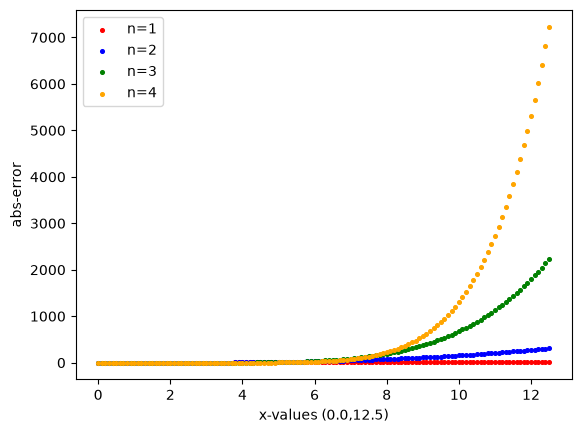

In [45]:
def main():
    
    if discussionAnalysisMode:
        hw2Func(0,np.pi)
        hw2Func(np.pi,2*np.pi)
        hw2Func(2*np.pi,3*np.pi)
        hw2Func(3*np.pi,4*np.pi)
    else:
        hw2Func(0,4*np.pi)

main()